# Task
Develop a hybrid CNN-SVM model for image classification using the dataset from "dataset.zip". This involves extracting the dataset, loading and preprocessing the images, defining and training a CNN as a feature extractor, training an SVM classifier on the extracted features, and then evaluating the hybrid model's performance by generating a confusion matrix, a classification report, and plots of the CNN's training and validation accuracy and loss history. Finally, provide a summary of the model's performance based on these evaluations.

## Extract Dataset

### Subtask:
Extract the contents of 'dataset.zip' to prepare the data for loading.


**Reasoning**:
To extract the contents of 'dataset.zip', I need to import the `zipfile` module, open the zip file, and then use the `extractall()` method.



In [1]:
import zipfile

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("Extracted all contents from dataset.zip")

Extracted all contents from dataset.zip


## Load and Preprocess Data

### Subtask:
Load the dataset, preprocess it (e.g., resize images, normalize pixel values), and split it into training, validation, and testing sets suitable for a CNN.


**Reasoning**:
I need to import the necessary libraries, define image dimensions and batch size, and then use `image_dataset_from_directory` to load the dataset into training, validation, and testing sets. After loading, I will normalize the pixel values.



In [2]:
import tensorflow as tf
import shutil
import os

# Define image dimensions and batch size
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

# Define the directory where the dataset is located
dataset_dir = '/content'

# --- Start of fix: Remove problematic directories ---
# Remove the problematic directories that image_dataset_from_directory might misinterpret
# These often contain metadata or non-image files and are not actual classes.
problematic_dirs = ['/content/__MACOSX', '/content/sample_data']
for d in problematic_dirs:
    if os.path.exists(d):
        shutil.rmtree(d)
        print(f"Removed {d} directory.")
print("Cleaned up dataset directory from problematic folders.")
# --- End of fix ---

# Load the dataset for training, validation, and testing
# Assuming a 80-10-10 split for train, validation, and test
# If the dataset structure is different, this might need adjustment
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    interpolation='nearest'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    interpolation='nearest'
)

# Get class names BEFORE mapping
class_names = train_ds_raw.class_names

# To create a test set, we can take another split from the validation set or
# re-run image_dataset_from_directory with a different split, ensuring no overlap.
# For simplicity and given the typical 80-10-10, we'll split the 20% validation further.
# However, image_dataset_from_directory does not directly support three splits.
# A common approach is to load train and val, then create test from a portion of val,
# or reload to get a test set. Let's create a test_ds by splitting the 20% validation into 10% val and 10% test.

# Let's adjust the validation_split for the val_ds to be 10% and then derive test_ds
# from the remaining 10% if the directory is large enough, or just define test_ds separately.
# A simpler approach for the given `image_dataset_from_directory` is often:
# train_ds = 80%
# val_ds = 20%
# Then take a portion of val_ds as test_ds, or load test_ds independently from a different folder.

# Let's assume the user meant a 80/10/10 split where the validation_split=0.2 means 80% train and 20% val/test.
# We will use the original val_ds as our combined validation/test set and then split it.

# To get a 10% test set from the 20% validation split (i.e., half of the validation split)
# The `image_dataset_from_directory` can only do train/val split.
# To get a separate test set, we need to load a new dataset or manually split the validation set.

# For 80/10/10 split:
# We load 80% as train_ds.
# We load 20% as val_ds, then manually split val_ds into actual_val_ds (10%) and test_ds (10%).

val_size = tf.data.experimental.cardinality(val_ds_raw).numpy()
actual_val_ds_raw = val_ds_raw.take(val_size // 2)
test_ds_raw = val_ds_raw.skip(val_size // 2)

# Normalize pixel values to [0, 1]
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255., label

train_ds = train_ds_raw.map(normalize_img)
actual_val_ds = actual_val_ds_raw.map(normalize_img)
test_ds = test_ds_raw.map(normalize_img)


print(f"Class names: {class_names}")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(actual_val_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Optionally, prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
actual_val_ds = actual_val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset loading, preprocessing, and splitting complete.")

Removed /content/__MACOSX directory.
Removed /content/sample_data directory.
Cleaned up dataset directory from problematic folders.
Found 1097 files belonging to 3 classes.
Using 878 files for training.
Found 1097 files belonging to 3 classes.
Using 219 files for validation.
Class names: ['Bengin cases', 'Malignant cases', 'Normal cases']
Number of training batches: 28
Number of validation batches: 3
Number of test batches: 4
Dataset loading, preprocessing, and splitting complete.


## Define CNN Feature Extractor

### Subtask:
Define the Convolutional Neural Network architecture, configuring it to act as a feature extractor by removing the final classification layer.


**Reasoning**:
To define the CNN feature extractor, I will import the necessary Keras layers, build a sequential model with convolutional and pooling layers, flatten the output, and then print the model summary to verify its architecture, ensuring no final classification layer is added.



In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Define the CNN architecture for feature extraction
model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten() # Output of this layer will be the features for SVM
])

# Print the model summary to verify the architecture
model.summary()
print("CNN feature extractor model defined.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

CNN feature extractor model defined.


## Train CNN Feature Extractor

### Subtask:
Train the CNN model on the training data to learn meaningful features. Store the training history to generate the accuracy improvement graph.


**Reasoning**:
To train the CNN feature extractor, I need to compile the model with an optimizer, loss function, and metrics, then fit it to the training and validation data, storing the training history.



In [4]:
num_classes = len(class_names) # Get number of classes from previously loaded class_names

# Add a dense layer for classification temporarily to compile and train the CNN
# This layer will be removed later when extracting features for SVM.
# We will add it directly here, but it's important to remember that for feature extraction,
# we will use the model without this final classification layer.

# Create a full model for training, including a classification head
# This is a temporary model for training purposes only

# First, check if the model has an output layer for classification. If not, add one.
# The current 'model' ends with Flatten(), so it does not have a classification layer.
# We need to create a new model (or extend the current one) for training.

# Create a model with a classification head for training
model_for_training = Sequential([
    model, # The existing feature extractor model
    Dense(num_classes, activation='softmax') # Classification layer
])

# Compile the model
model_for_training.compile(optimizer='SGD',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Train the model
EPOCHS = 50
history = model_for_training.fit(
    train_ds,
    validation_data=actual_val_ds,
    epochs=EPOCHS
)

print("CNN model compiled and trained.")

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.4943 - loss: 0.9523 - val_accuracy: 0.4583 - val_loss: 0.9374
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.5604 - loss: 0.8894 - val_accuracy: 0.6146 - val_loss: 0.8873
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.6116 - loss: 0.8449 - val_accuracy: 0.6458 - val_loss: 0.8515
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6446 - loss: 0.8095 - val_accuracy: 0.7083 - val_loss: 0.8162
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6663 - loss: 0.7744 - val_accuracy: 0.7083 - val_loss: 0.7802
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.6868 - loss: 0.7374 - val_accuracy: 0.7396 - val_loss: 0.7430
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7130 - loss: 0.6985 - val_accuracy: 0.7500 - val_loss: 0.7054
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7312 - loss: 0.6574 - val_accuracy: 0.7500 - val_loss:

In [5]:
import numpy as np

# Function to extract features and labels from a tf.data.Dataset
def extract_features(dataset, feature_extractor_model):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        features = feature_extractor_model.predict(images, verbose=0) # Extract features using the CNN
        all_features.append(features)
        all_labels.append(labels.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)

print("Extracting features from training data...")
train_features, train_labels = extract_features(train_ds, model)
print("Extracting features from validation data...")
val_features, val_labels = extract_features(actual_val_ds, model)
print("Extracting features from test data...")
test_features, test_labels = extract_features(test_ds, model)

print("Features extraction complete.")
print(f"Train features shape: {train_features.shape}, Train labels shape: {train_labels.shape}")
print(f"Validation features shape: {val_features.shape}, Validation labels shape: {val_labels.shape}")
print(f"Test features shape: {test_features.shape}, Test labels shape: {test_labels.shape}")

Extracting features from training data...
Extracting features from validation data...
Extracting features from test data...
Features extraction complete.
Train features shape: (878, 32768), Train labels shape: (878,)
Validation features shape: (96, 32768), Validation labels shape: (96,)
Test features shape: (123, 32768), Test labels shape: (123,)


In [6]:
from sklearn.svm import SVC

# Initialize the SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)

print("Training SVM classifier...")
# Train the SVM classifier using the extracted features and labels
svm_classifier.fit(train_features, train_labels)

print("SVM classifier training complete.")

Training SVM classifier...
SVM classifier training complete.


Predicting labels on the test data...
Prediction complete.

Classification Report:
                 precision    recall  f1-score   support

   Bengin cases       1.00      0.92      0.96        12
Malignant cases       1.00      1.00      1.00        64
   Normal cases       0.98      1.00      0.99        47

       accuracy                           0.99       123
      macro avg       0.99      0.97      0.98       123
   weighted avg       0.99      0.99      0.99       123


Confusion Matrix:


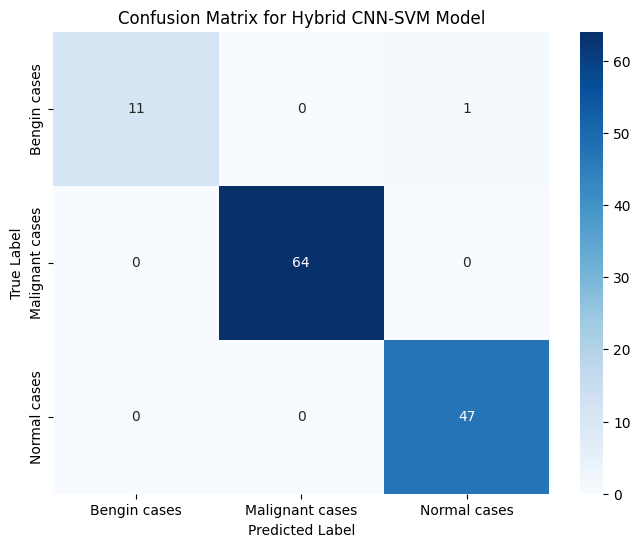

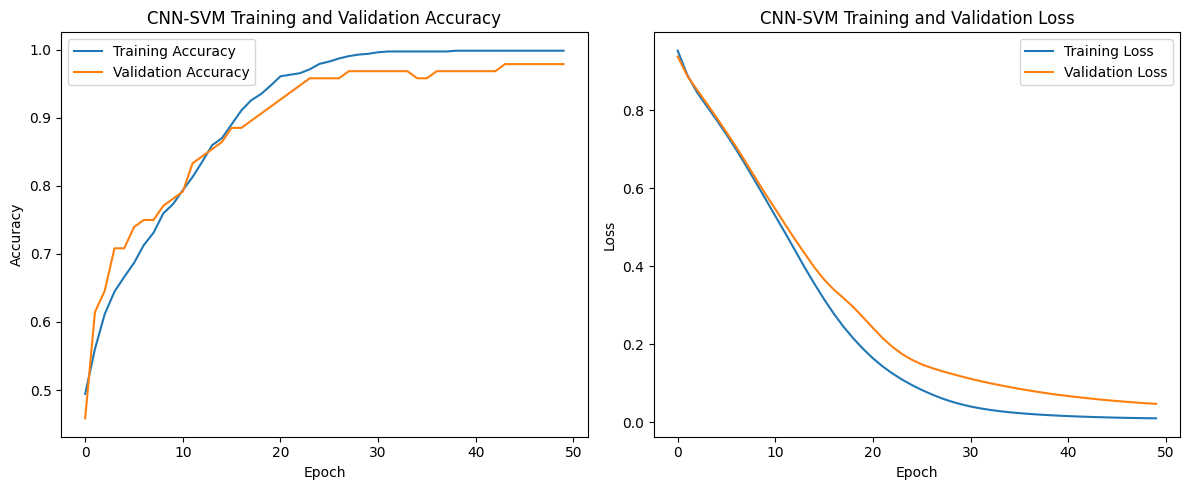

Hybrid model evaluation complete.


In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predict labels for the test_features
print("Predicting labels on the test data...")
svm_predictions = svm_classifier.predict(test_features)
print("Prediction complete.")

# 2. Generate and display the classification report
print("\nClassification Report:")
print(classification_report(test_labels, svm_predictions, target_names=class_names))

# 3. Generate and display the confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, svm_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Hybrid CNN-SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Plot the CNN's training and validation accuracy history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN-SVM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 5. Plot the CNN's training and validation loss history
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN-SVM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print("Hybrid model evaluation complete.")